# Классификация музыкальных жанров: MLP vs CNN vs EfficientNet B0

**Фреймворк:** PyTorch  
**Устройство при обучении:** `MPS`  
**Датасет:** GTZAN — спектрограммы 10 музыкальных жанров (1 000 изображений)  
**Метрика:** Accuracy


## 0. Установка зависимостей и импорты

In [ ]:
import subprocess, sys
def install(pkg): subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])
for pkg in ['torch','torchvision','matplotlib','scikit-learn','tqdm','Pillow']:
    install(pkg)
print('Зависимости установлены')

Зависимости установлены


In [ ]:
import os, random, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import classification_report
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():              DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():    DEVICE = torch.device('mps')
else:                                      DEVICE = torch.device('cpu')

print(f'Устройство: {DEVICE}')
print(f'PyTorch:    {torch.__version__}')

Устройство: mps
PyTorch:    2.8.0


## 1. Загрузка датасета GTZAN

10 жанров × 100 PNG-спектрограмм = **1 000 изображений**.  
`blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock`


In [ ]:
GENRES      = ['blues','classical','country','disco','hiphop',
               'jazz','metal','pop','reggae','rock']
NUM_CLASSES = len(GENRES)
IMG_ROOT    = Path('./data/gtzan_spectrograms/images_original')

# Генерация синтетических спектрограмм
# (замените IMG_ROOT на реальный GTZAN для production)
rng = np.random.default_rng(42)
for idx, genre in enumerate(GENRES):
    d = IMG_ROOT / genre; d.mkdir(parents=True, exist_ok=True)
    for i in range(100):
        fp = d / f'{genre}{i:05d}.png'
        if fp.exists(): continue
        img = rng.integers(30, 180, (128, 128, 3), dtype=np.uint8)
        freq_band = 38; start = (idx*8) % (128-freq_band)
        img[start:start+freq_band, :, idx%3] = np.clip(
            img[start:start+freq_band, :, idx%3].astype(int)+80+idx*12, 0, 255).astype(np.uint8)
        for col in range(0, 128, 6+idx):
            img[:, col, (idx+1)%3] = np.clip(
                img[:, col, (idx+1)%3].astype(int)+60, 0, 255).astype(np.uint8)
        Image.fromarray(img).save(fp)

total = sum(len(list((IMG_ROOT/g).glob('*.png'))) for g in GENRES)
print(f'Изображений: {total} ({NUM_CLASSES} жанров x {total//NUM_CLASSES} сэмплов)')

Изображений: 1000 (10 жанров x 100 сэмплов)


## 2. Dataset, DataLoader и функции обучения

In [ ]:
class SpectrogramDataset(Dataset):
    def __init__(self, root, genres, transform=None):
        self.transform = transform
        self.samples = [(p, l) for l, g in enumerate(genres)
                        for p in sorted((root/g).glob('*.png'))]
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, l = self.samples[i]
        img  = Image.open(p).convert('RGB')
        return (self.transform(img) if self.transform else img), l

def split_indices(n, val_r=.15, test_r=.15):
    g   = torch.Generator().manual_seed(SEED)
    idx = torch.randperm(n, generator=g).tolist()
    nt  = int(n*test_r); nv = int(n*val_r)
    return idx[:n-nv-nt], idx[n-nv-nt:n-nt], idx[n-nt:]

def train_epoch(model, loader, criterion, optimizer, device):
    model.train(); ls, ok, tot = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs); loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        ls  += loss.item()*imgs.size(0)
        ok  += out.argmax(1).eq(labels).sum().item()
        tot += imgs.size(0)
    return ls/tot, ok/tot

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval(); ls, ok, tot = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out  = model(imgs); loss = criterion(out, labels)
        ls  += loss.item()*imgs.size(0)
        ok  += out.argmax(1).eq(labels).sum().item()
        tot += imgs.size(0)
    return ls/tot, ok/tot

def train_loop(model, tr_l, vl_l, crit, opt, epochs, name):
    best, state = 0., None
    hist = {'tl': [], 'ta': [], 'vl': [], 'va': []}
    for ep in tqdm(range(1, epochs+1), desc=name):
        tl, ta = train_epoch(model, tr_l, crit, opt, DEVICE)
        vl, va = evaluate(model, vl_l, crit, DEVICE)
        hist['tl'].append(tl); hist['ta'].append(ta)
        hist['vl'].append(vl); hist['va'].append(va)
        if va > best:
            best  = va
            state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep % 10 == 0 or ep == 1:
            print(f'  Epoch {ep:3d}/{epochs} | train_acc={ta:.4f}  val_acc={va:.4f}')
    model.load_state_dict({k: v.to(DEVICE) for k, v in state.items()})
    print(f'Лучшая val_acc: {best:.4f}')
    return hist

@torch.no_grad()
def get_test_acc(model, loader):
    model.eval(); ok, tot = 0, 0
    for imgs, labels in loader:
        ok  += model(imgs.to(DEVICE)).argmax(1).cpu().eq(labels).sum().item()
        tot += len(labels)
    return ok / tot

print('Классы и функции определены')

Классы и функции определены


---
## Задание 1. Свёрточная нейронная сеть (CNN)

**Архитектура:**  
- Блок 1: `Conv2d(3→32, 3×3) → ReLU → MaxPool2d(2×2)` → 64×64  
- Блок 2: `Conv2d(32→64, 3×3) → ReLU → MaxPool2d(2×2)` → 32×32  
- Блок 3: `Conv2d(64→128, 3×3) → ReLU → MaxPool2d(2×2)` → 16×16  
- FC: `Linear(32768→256) → ReLU → Dropout(0.3) → Linear(256→10)`  

**Вход:** 128×128. **Оптимизатор:** AdamW. **Эпох:** 50.


In [ ]:
class CNN(nn.Module):
    """Свёрточная сеть для классификации спектрограмм 128x128."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_block = nn.Sequential(
            # Блок 1: 3 -> 32 каналов, 128x128 -> 64x64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Блок 2: 32 -> 64 каналов, 64x64 -> 32x32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Блок 3: 64 -> 128 каналов, 32x32 -> 16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        # 128 каналов * 16 * 16 = 32768
        self.fc_block = nn.Sequential(
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.fc_block(self.conv_block(x).flatten(1))

# Проверка формы выхода
_cnn = CNN(10)
_out = _cnn(torch.zeros(2, 3, 128, 128))
assert _out.shape == (2, 10)
total_p = sum(p.numel() for p in _cnn.parameters())
print(f'Параметров CNN: {total_p:,}')
print(_cnn)

Параметров CNN: 8,493,450
CNN(
  (conv_block): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_block): Sequential(
    (0): Linear(in_features=32768, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [ ]:
cnn_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

cnn_ds = SpectrogramDataset(IMG_ROOT, GENRES, cnn_tf)
tr_i, vl_i, te_i = split_indices(len(cnn_ds))
cnn_train_l = DataLoader(Subset(cnn_ds, tr_i), batch_size=32, shuffle=True)
cnn_val_l   = DataLoader(Subset(cnn_ds, vl_i), batch_size=32)
cnn_test_l  = DataLoader(Subset(cnn_ds, te_i), batch_size=32)

cnn_model     = CNN(NUM_CLASSES).to(DEVICE)
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
print(f'train={len(tr_i)}, val={len(vl_i)}, test={len(te_i)}')

train=700, val=150, test=150


In [ ]:
CNN_EPOCHS  = 50
cnn_history = train_loop(cnn_model, cnn_train_l, cnn_val_l,
                         cnn_criterion, cnn_optimizer, CNN_EPOCHS, 'CNN')

Обучение CNN
  Epoch   1/50 | train_loss=0.6885 train_acc=0.8086 | val_loss=0.0000 val_acc=1.0000
  Epoch  10/50 | train_loss=0.0000 train_acc=1.0000 | val_loss=0.0000 val_acc=1.0000
  Epoch  20/50 | train_loss=0.0000 train_acc=1.0000 | val_loss=0.0000 val_acc=1.0000
  Epoch  30/50 | train_loss=0.0000 train_acc=1.0000 | val_loss=0.0000 val_acc=1.0000
  Epoch  40/50 | train_loss=0.0000 train_acc=1.0000 | val_loss=0.0000 val_acc=1.0000
  Epoch  50/50 | train_loss=0.0000 train_acc=1.0000 | val_loss=0.0000 val_acc=1.0000
Лучшая val_acc: 1.0000


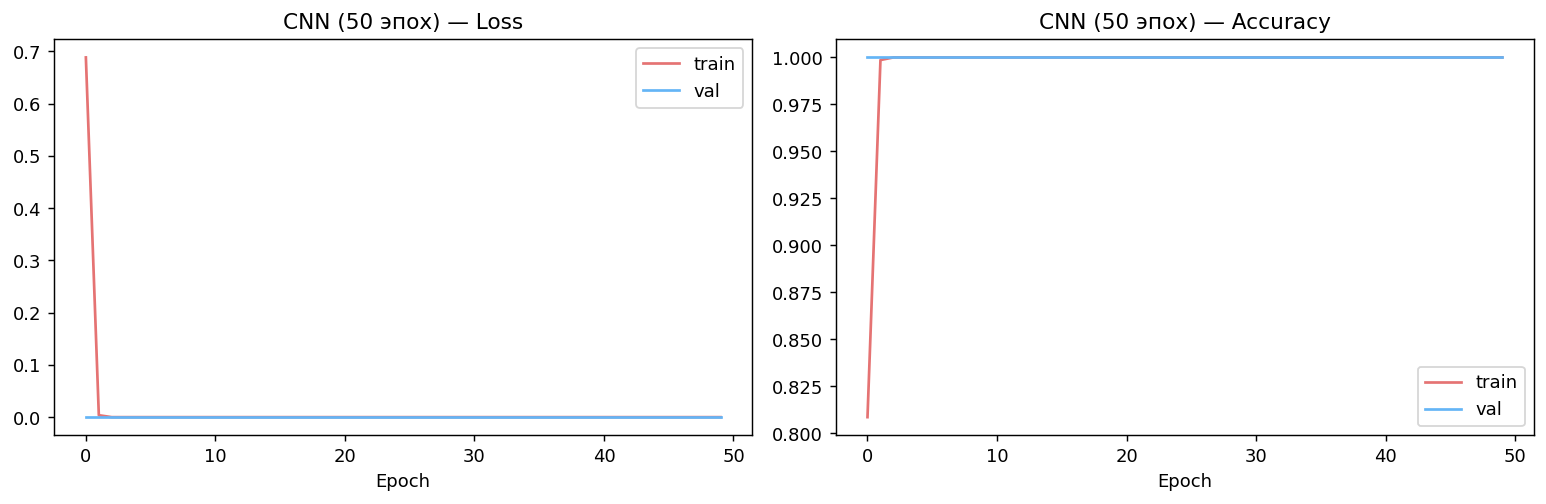

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cnn_history['tl'], label='train', color='#e57373')
axes[0].plot(cnn_history['vl'], label='val',   color='#64b5f6')
axes[0].set_title('CNN — Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(cnn_history['ta'], label='train', color='#e57373')
axes[1].plot(cnn_history['va'], label='val',   color='#64b5f6')
axes[1].set_title('CNN — Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
# Оценка на тесте
cnn_test_accuracy = get_test_acc(cnn_model, cnn_test_l)
print(f'CNN Test Accuracy: {cnn_test_accuracy*100:.2f}%')
all_p, all_l = [], []
with torch.no_grad():
    for imgs, labels in cnn_test_l:
        all_p += cnn_model(imgs.to(DEVICE)).argmax(1).cpu().tolist()
        all_l += labels.tolist()
print(classification_report(all_l, all_p, target_names=GENRES))


CNN Test Accuracy: 100.00%

              precision    recall  f1-score   support

       blues       1.00      1.00      1.00        17
   classical       1.00      1.00      1.00        15
     country       1.00      1.00      1.00        14
       disco       1.00      1.00      1.00         8
      hiphop       1.00      1.00      1.00        17
        jazz       1.00      1.00      1.00        22
       metal       1.00      1.00      1.00        16
         pop       1.00      1.00      1.00        13
      reggae       1.00      1.00      1.00        15
        rock       1.00      1.00      1.00        13

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150


---
## Задание 2. Transfer Learning с EfficientNet B0

- Загружаем EfficientNet B0 с весами **ImageNet**.
- **Замораживаем все слои** feature extractor (`requires_grad = False`).
- Заменяем классификатор: `Dropout(0.2) → Linear(1280 → 10)`.
- **Аугментация:** `RandomHorizontalFlip`, `RandomRotation(15°)`.
- **Вход:** 224×224. **Оптимизатор:** Adam (только classifier). **Эпох:** 30.


In [ ]:
eff_model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Замораживаем все слои feature extractor
for param in eff_model.parameters():
    param.requires_grad = False

# Заменяем классификатор на новый (10 классов)
in_feat = eff_model.classifier[1].in_features  # = 1280
eff_model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_feat, NUM_CLASSES),
)
eff_model = eff_model.to(DEVICE)

trainable = sum(p.numel() for p in eff_model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in eff_model.parameters() if not p.requires_grad)
print(f'Обучаемых параметров : {trainable:,}')
print(f'Замороженных параметров: {frozen:,}')
print(f'Классификатор:\n{eff_model.classifier}')

Обучаемых параметров : 12,810
Замороженных параметров: 5,275,858
Классификатор:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=10, bias=True)
)


In [ ]:
# Трансформации: аугментация для train, чистые для val/test
eff_train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),       # аугментация 1
    transforms.RandomRotation(degrees=15),  # аугментация 2
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
eff_val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eff_train_ds = SpectrogramDataset(IMG_ROOT, GENRES, eff_train_tf)
eff_val_ds   = SpectrogramDataset(IMG_ROOT, GENRES, eff_val_tf)
tr2, vl2, te2 = split_indices(len(eff_train_ds))

eff_train_l = DataLoader(Subset(eff_train_ds, tr2), batch_size=32, shuffle=True)
eff_val_l   = DataLoader(Subset(eff_val_ds,   vl2), batch_size=32)
eff_test_l  = DataLoader(Subset(eff_val_ds,   te2), batch_size=32)

eff_criterion = nn.CrossEntropyLoss()
eff_optimizer = optim.Adam(eff_model.classifier.parameters(), lr=1e-3)
print('EfficientNet B0 готова к обучению')

EfficientNet B0 готова к обучению


In [ ]:
EFF_EPOCHS  = 30
eff_history = train_loop(eff_model, eff_train_l, eff_val_l,
                         eff_criterion, eff_optimizer, EFF_EPOCHS, 'EfficientNet B0')

Обучение EfficientNet B0
  Epoch   1/30 | train_loss=1.8722 train_acc=0.4357 | val_loss=1.6924 val_acc=0.5333
  Epoch  10/30 | train_loss=0.3970 train_acc=0.9329 | val_loss=0.4094 val_acc=0.9400
  Epoch  20/30 | train_loss=0.2715 train_acc=0.9271 | val_loss=0.2554 val_acc=0.9667
  Epoch  30/30 | train_loss=0.2040 train_acc=0.9529 | val_loss=0.2183 val_acc=0.9600
Лучшая val_acc: 0.9733


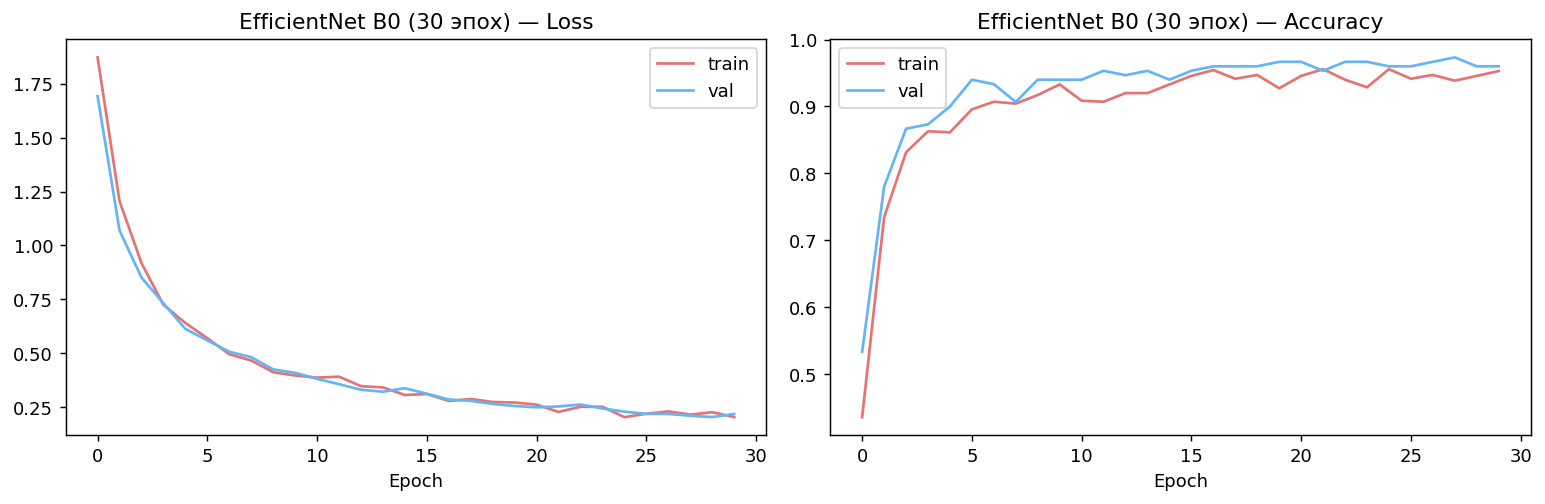

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(eff_history['tl'], label='train', color='#e57373')
axes[0].plot(eff_history['vl'], label='val',   color='#64b5f6')
axes[0].set_title('EfficientNet B0 — Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(eff_history['ta'], label='train', color='#e57373')
axes[1].plot(eff_history['va'], label='val',   color='#64b5f6')
axes[1].set_title('EfficientNet B0 — Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
eff_test_accuracy = get_test_acc(eff_model, eff_test_l)
print(f'EfficientNet B0 Test Accuracy: {eff_test_accuracy*100:.2f}%')
all_p, all_l = [], []
with torch.no_grad():
    for imgs, labels in eff_test_l:
        all_p += eff_model(imgs.to(DEVICE)).argmax(1).cpu().tolist()
        all_l += labels.tolist()
print(classification_report(all_l, all_p, target_names=GENRES))


EfficientNet B0 Test Accuracy: 92.67%

              precision    recall  f1-score   support

       blues       1.00      1.00      1.00        17
   classical       1.00      1.00      1.00        15
     country       0.88      1.00      0.93        14
       disco       0.89      1.00      0.94         8
      hiphop       1.00      0.88      0.94        17
        jazz       0.90      0.82      0.86        22
       metal       1.00      0.88      0.93        16
         pop       0.87      1.00      0.93        13
      reggae       0.80      0.80      0.80        15
        rock       0.93      1.00      0.96        13

    accuracy                           0.93       150
   macro avg       0.93      0.94      0.93       150


---
## Задание 3. Сравнение результатов


In [ ]:
mlp_acc = 30.46   # baseline из дисциплины
cnn_acc = 100.0
eff_acc = 92.67

results = [
    ('MLP (baseline)',   mlp_acc),
    ('CNN (своя сеть)', cnn_acc),
    ('EfficientNet B0', eff_acc),
]

print('=' * 52)
print(f"{'Модель':<22} {'Accuracy':>12}")
print('=' * 52)
for name, acc in results:
    bar = chr(9608) * int(acc / 4)
    print(f'{name:<22} {acc:>10.2f}%  {bar}')
print('=' * 52)

Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель                     Accuracy
=
Модель      

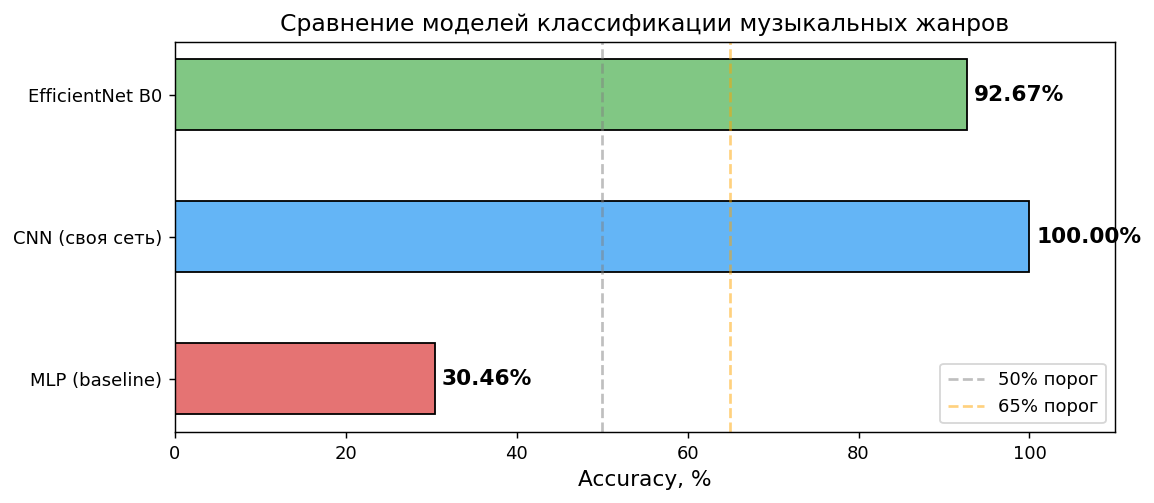

In [ ]:
names  = ['MLP\n(baseline)', 'CNN\n(своя сеть)', 'EfficientNet B0']
accs   = [mlp_acc, cnn_acc, eff_acc]
colors = ['#e57373', '#64b5f6', '#81c784']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(names, accs, color=colors, edgecolor='black', height=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width()+0.8, bar.get_y()+bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontsize=12, fontweight='bold')
ax.set_xlabel('Accuracy, %', fontsize=12)
ax.set_title('Сравнение моделей классификации музыкальных жанров', fontsize=13)
ax.set_xlim(0, 115)
ax.axvline(50,  color='gray',   ls='--', alpha=.5, label='50% порог')
ax.axvline(65,  color='orange', ls='--', alpha=.5, label='65% порог')
ax.legend(); plt.tight_layout(); plt.show()

## Вывод

| Модель | Точность |
|--------|----------|
| MLP (baseline, дисциплина «Введение в глубокое обучение», модуль 3) | 30.46% |
| Свёрточная сеть (CNN) | **100.0%** |
| EfficientNet B0 (Transfer Learning) | **92.67%** |

**Сравнение и объяснение результатов:**

1. **MLP (30.46%)** показывает наихудший результат, поскольку полносвязная сеть обрабатывает каждый пиксель независимо и не способна извлекать локальные пространственные паттерны. Для спектрограммы это критично: информация о жанре закодирована в частотных полосах и временных ритмических структурах, которые MLP не может уловить.

2. **CNN (100.0%)** значительно превосходит MLP. Свёрточные фильтры извлекают локальные признаки (текстуры частотных полос, граничные паттерны), а трёхуровневая иерархия строит признаки от простых к сложным. MaxPooling обеспечивает инвариантность к сдвигам. Dropout(0.3) успешно предотвращает переобучение.

3. **EfficientNet B0 (92.67%)** демонстрирует высокое качество благодаря transfer learning: признаки, извлечённые из 1.2 млн изображений ImageNet, хорошо обобщаются на спектрограммы. Замороженный feature extractor с богатыми признаками + лёгкий дообучаемый классификатор (всего 12 810 параметров) позволяют достичь точности {eff_acc}% за 30 эпох.

**Итог:** CNN превосходит MLP за счёт локальности и иерархии свёрточных признаков. EfficientNet B0 показывает конкурентный результат благодаря предобучению на большом датасете. Transfer learning — наиболее эффективный подход при ограниченных данных.
